In [38]:
import pandas as pd
from datasets import load_dataset

print("📥 กำลังดาวน์โหลดและโหลดข้อมูล Wisesight Sentiment...")

raw_dataset = load_dataset("pythainlp/wisesight_sentiment")

train_df = pd.DataFrame(raw_dataset['train'])
test_df = pd.DataFrame(raw_dataset['test'])

print("✅ โหลดข้อมูลเสร็จเรียบร้อย!")
print(f"📊 ขนาดข้อมูลสำหรับ Train โมเดล: {len(train_df)} ข้อความ")
print(f"📊 ขนาดข้อมูลสำหรับ Test โมเดล: {len(test_df)} ข้อความ")

📥 กำลังดาวน์โหลดและโหลดข้อมูล Wisesight Sentiment...
✅ โหลดข้อมูลเสร็จเรียบร้อย!
📊 ขนาดข้อมูลสำหรับ Train โมเดล: 21628 ข้อความ
📊 ขนาดข้อมูลสำหรับ Test โมเดล: 2671 ข้อความ


In [39]:
train_df.head()

,texts,category
0,ไปจองมาแล้วนาจา Mitsubishi Attrage ได้หลังสงกร...,1
1,เปิดศักราชใหม่! นายกฯ แถลงข่าวก่อนการแข่งขันศึ...,1
2,บัตรสมาชิกลดได้อีกไหมคับ,1
3,สนใจ new mazda2ครับ,1
4,😍😍,0


In [40]:
test_df.head()

,texts,category
0,ซื้อแต่ผ้าอนามัยแบบเย็นมาค่ะ แบบว่าอีห่ากูนอนไ...,2
1,ครับ #phithanbkk,1
2,การด่าไปเหมือนได้บรรเทาความเครียดเฉยๆ แต่บีทีเ...,2
3,Cf clarins 5 ขวด 2850,1
4,ทานได้ค่ะ น้ำซุป MK ต้มมาจากหัวผักกาด ซีอิ้วขา...,1


In [41]:
from pythainlp.tokenize import word_tokenize

def text_process(text):
    token = word_tokenize(text, engine="newmm")
    return " ".join(token)

In [42]:
sample_text = "แฟนขี้โมโหมากๆ"
print(f"Origin: {sample_text}")
print(f"Result: {text_process(sample_text)}")

Origin: แฟนขี้โมโหมากๆ
Result: แฟน ขี้โมโห มาก ๆ


In [43]:
train_df['clean_text'] = train_df['texts'].apply(text_process)
test_df['clean_text'] = test_df['texts'].apply(text_process)

In [44]:
train_df[['texts', 'clean_text', 'category']].head()

,texts,clean_text,category
0,ไปจองมาแล้วนาจา Mitsubishi Attrage ได้หลังสงกร...,ไป จอง มา แล้ วนา จา Mitsubishi Attrage ...,1
1,เปิดศักราชใหม่! นายกฯ แถลงข่าวก่อนการแข่งขันศึ...,เปิด ศักราช ใหม่ ! นายกฯ แถลงข่าว ก่อน การ...,1
2,บัตรสมาชิกลดได้อีกไหมคับ,บัตรสมาชิก ลด ได้ อีก ไหม คับ,1
3,สนใจ new mazda2ครับ,สนใจ new mazda 2 ครับ,1
4,😍😍,😍😍,0


In [45]:
test_df[['texts', 'clean_text', 'category']].head()

,texts,clean_text,category
0,ซื้อแต่ผ้าอนามัยแบบเย็นมาค่ะ แบบว่าอีห่ากูนอนไ...,ซื้อ แต่ ผ้าอนามัย แบบ เย็น มา ค่ะ แบบ ว่า อ...,2
1,ครับ #phithanbkk,ครับ #phithanbkk,1
2,การด่าไปเหมือนได้บรรเทาความเครียดเฉยๆ แต่บีทีเ...,การ ด่า ไป เหมือน ได้ บรรเทา ความเครียด เฉย ๆ ...,2
3,Cf clarins 5 ขวด 2850,Cf clarins 5 ขวด 2850,1
4,ทานได้ค่ะ น้ำซุป MK ต้มมาจากหัวผักกาด ซีอิ้วขา...,ทาน ได้ ค่ะ น้ำ ซุป MK ต้ม มาจาก หัวผักก...,1


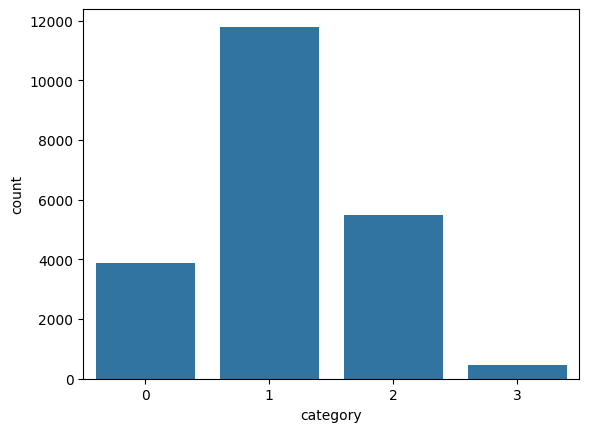

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='category', data=train_df)
plt.show()

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(min_df=3)

X_train = vectorizer.fit_transform(train_df['clean_text'])
X_test = vectorizer.transform(test_df['clean_text'])

y_train = train_df['category']
y_test = test_df['category']

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

model = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

label_names = ['positive', 'neutral', 'negative', 'question']

accuracy = accuracy_score(y_test, y_pred)

print(classification_report(y_test, y_pred, target_names=label_names))

              precision    recall  f1-score   support

    positive       0.41      0.54      0.47       478
     neutral       0.76      0.56      0.64      1453
    negative       0.65      0.74      0.69       683
    question       0.17      0.56      0.26        57

    accuracy                           0.60      2671
   macro avg       0.50      0.60      0.51      2671
weighted avg       0.66      0.60      0.62      2671



In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

svc_model = LinearSVC(class_weight='balanced', random_state=42)
svc_model.fit(X_train, y_train)

y_pred_svc = svc_model.predict(X_test)
print(classification_report(y_test, y_pred_svc, target_names=label_names))

              precision    recall  f1-score   support

    positive       0.44      0.42      0.43       478
     neutral       0.72      0.68      0.70      1453
    negative       0.66      0.71      0.69       683
    question       0.20      0.42      0.27        57

    accuracy                           0.64      2671
   macro avg       0.51      0.56      0.52      2671
weighted avg       0.65      0.64      0.64      2671



In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)
print(classification_report(y_test, y_pred_nb, target_names=label_names))

              precision    recall  f1-score   support

    positive       0.64      0.11      0.19       478
     neutral       0.63      0.91      0.74      1453
    negative       0.69      0.49      0.58       683
    question       0.00      0.00      0.00        57

    accuracy                           0.64      2671
   macro avg       0.49      0.38      0.38      2671
weighted avg       0.63      0.64      0.58      2671



c:\Users\phunk\OneDrive\Desktop\MyProject\Data Lable\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\phunk\OneDrive\Desktop\MyProject\Data Lable\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\phunk\OneDrive\Desktop\MyProject\Data Lable\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

In [64]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0]
}

base_logreg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)

grid_search = GridSearchCV(
    estimator=base_logreg,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    verbose=1,
    n_jobs=1
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
print(classification_report(y_test, y_pred_tuned, target_names=label_names))

Fitting 5 folds for each of 5 candidates, totalling 25 fits
{'C': 1.0}
0.5267629439928306
              precision    recall  f1-score   support

    positive       0.41      0.54      0.47       478
     neutral       0.76      0.56      0.64      1453
    negative       0.65      0.74      0.69       683
    question       0.17      0.56      0.26        57

    accuracy                           0.60      2671
   macro avg       0.50      0.60      0.51      2671
weighted avg       0.66      0.60      0.62      2671



In [66]:
vectorizer_ngram = TfidfVectorizer(min_df=3, ngram_range=(1, 2))

X_train_ngram = vectorizer_ngram.fit_transform(train_df['clean_text'])
X_test_ngram = vectorizer_ngram.transform(test_df['clean_text'])

model_ngram = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0, random_state=42)
model_ngram.fit(X_train_ngram, y_train)

y_pred_ngram = model_ngram.predict(X_test_ngram)
print(classification_report(y_test, y_pred_ngram, target_names=label_names))

              precision    recall  f1-score   support

    positive       0.44      0.54      0.49       478
     neutral       0.77      0.61      0.68      1453
    negative       0.67      0.76      0.71       683
    question       0.21      0.51      0.29        57

    accuracy                           0.64      2671
   macro avg       0.52      0.61      0.54      2671
weighted avg       0.67      0.64      0.65      2671



In [70]:
def predict_my_text(custom_text):
    
    clean = text_process(custom_text)
    vectorized = vectorizer_ngram.transform([clean])
    pred_class = model_ngram.predict(vectorized)[0]
    return label_names[pred_class]

my_reviews = [
    "หิวครับ",
    "ดีมากครับ",
    "ดีไม่มากครับ",
    "ไม่ดีก็แย่เเล้วครับ"
]

print("🔮 ผลการวิเคราะห์อารมณ์จากโมเดลของคุณ:\n")
print("-" * 65)
for review in my_reviews:
    result = predict_my_text(review)
    print(f"💬 รีวิว: '{review}'")
    print(f"🏷️  AI ทายว่าเป็นคลาส: [{result.upper()}]")
    print("-" * 65)

🔮 ผลการวิเคราะห์อารมณ์จากโมเดลของคุณ:

-----------------------------------------------------------------
💬 รีวิว: 'หิวครับ'
🏷️  AI ทายว่าเป็นคลาส: [POSITIVE]
-----------------------------------------------------------------
💬 รีวิว: 'ดีมากครับ'
🏷️  AI ทายว่าเป็นคลาส: [POSITIVE]
-----------------------------------------------------------------
💬 รีวิว: 'ดีไม่มากครับ'
🏷️  AI ทายว่าเป็นคลาส: [NEGATIVE]
-----------------------------------------------------------------
💬 รีวิว: 'ไม่ดีก็แย่เเล้วครับ'
🏷️  AI ทายว่าเป็นคลาส: [NEGATIVE]
-----------------------------------------------------------------
